**Author**: Felipe Matheus  
**Start Date**: 06/05/2026  
**End Date**: --/--/2026  
**Related Links**:

- Results so far: https://docs.google.com/spreadsheets/d/1OnIWY_bKxgdGU3trECDTL971WfXFPWgbW-dQzgP6KhI/edit?gid=0#gid=0
- Dataset used: https://drive.google.com/drive/u/0/folders/1VsU-taxtwfmDLUu5Z4JmdgXSoxUoB8FI

**Objective**

Build an uncertainty-aware probabilistic predictor of conductivity (IACS) after the **annealing** process, using AutoGluon. The output of every prediction is a Gaussian-like predictive distribution $\mathcal{N}(\hat\mu, \hat\sigma^2)$ where the variance is decomposed into epistemic and aleatoric components.

**Pipeline**

1. Setup and global configuration.
2. Load + preprocess data.
3. Train **Model A** (mean predictor with internal K-fold bagging).
4. Extract OOF predictions per base learner.
5. Recover ensemble weights via NNLS; compute weighted $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$.
6. Build aleatoric targets $\tilde r^2 = \max(r^2_{\text{OOF}} - \hat\sigma^2_{\text{epist}}, 0)$.
7. Train **Model B** on $\log(\tilde r^2 + \epsilon)$.
8. Calibration diagnostics and scalar recalibration.

# 1. Setup

In [1]:
import os
import sys
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.processing.Processing import Processing
from src.feature_engineering.FeatureEngineering import FeatureEngineering
from src.modeling.Modeling import Modeling
from config.Variables import Variables

%load_ext autoreload
%autoreload 2

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Helper instances reused across the notebook.
proc = Processing()
feng = FeatureEngineering()
mdl = Modeling()
varv = Variables()

## 1.1 Global configuration

All knobs that may change between surrogates / processes / experiments live here. Other notebooks for other surrogates only need to edit this cell.

In [46]:
# ---- Experiment settings ----
TAG = "full_features_"
SCHEMA_DATE = "080626"

# ---- Paths ----
PATH_DATA_RAW = "../../data/raw"
PATH_MODELS = "../../models"
FILE_NAME = "dataset_annealing_iacs.csv"
FILE_NAME_SCHEMA_DATA = "schema_annealing_essays_{}.csv".format(SCHEMA_DATE)
PROCESS = "annealing_iacs"

# ---- Dataset schema ----
TARGET = "iacs_final"
FEATURES = ["purity", "iacs", "temperature", "time"]
WEIGHT_ON_ESSAY_ROWS = 3

# ---- AutoGluon training knobs (Model A) ----
PRESETS_A = "best_quality"     # 'best_quality' for final runs only or medium_quality
NUM_BAG_FOLDS_A = 5               # K-fold bagging produces OOF preds
NUM_BAG_SETS_A = 1
NUM_STACK_LEVELS_A = 0            # no multi-level stacking; keep simple
TIME_LIMIT_A = 120

# ---- AutoGluon training knobs (Model B) ----
PRESETS_B = "best_quality"
NUM_BAG_FOLDS_B = 5
NUM_STACK_LEVELS_B = 0
TIME_LIMIT_B = 60

# ---- Uncertainty pipeline knobs ----
USE_WEIGHTED_VARIANCE = True      # False = uniform mean/var (sanity check)
VARIANCE_FLOOR_FRAC = 0.01        # floor of σ²_aleat as fraction of Var(y)
CALIBRATION_ALPHAS = (0.5, 0.8, 0.9, 0.95)
RECALIBRATION_TARGET_ALPHA = 0.9

In [30]:
FILE_NAME_SCHEMA_DATA

'schema_annealing_essays_080626.csv'

In [28]:
s.format("test")

'string_test'

# 2. Data

## 2.1 Schema data

In [54]:
# Schema dataset.
df_raw_schema = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME_SCHEMA_DATA))
df_schema = df_raw_schema[FEATURES + [TARGET]].dropna()
df_schema

,purity,iacs,temperature,time,iacs_final
0,99.9,88.260,623.0,30.0,88.350000
1,99.9,88.260,623.0,60.0,88.655000
2,99.9,88.260,623.0,90.0,88.800000
3,99.9,99.825,573.0,30.0,102.340000
4,99.9,99.390,573.0,30.0,102.230000
5,99.9,99.390,588.0,30.0,101.346667
6,99.9,99.230,573.0,30.0,101.355000
7,99.9,98.720,573.0,30.0,101.480000
17,99.9,100.250,573.0,30.0,102.755000


## 2.2 Literature data

In [4]:
# Raw CSV.
df_raw = pd.read_csv(os.path.join(PATH_DATA_RAW, FILE_NAME))
df_raw.head()

,material,purity,grain_size,iacs,temperature,time,grain_size_final,iacs_final
0,Cu,99.98,320,97,473,30,~500,100
1,Cu,99.98,320,97,523,600,~800,100
2,Cu,99.98,320,97,573,120,~900,103
3,Cu,99.98,320,96,473,30,~500,99
4,Cu,99.98,320,95,523,600,~800,98


In [44]:
# Cast to float, label material elements, mark rows where ratios are valid.
df_float = proc.df_to_float(
    df_raw, drop_cols=["DOI"], ignore_columns=["material"]
)
df_labeled = feng.label_element(df_float).drop_duplicates()
df_with_masks = feng.add_ratio_mask_column(
    feng.add_ratio_mask_column(df_labeled, "grain_size"),
    "iacs",
)

# Keep only copper rows and the schema columns.
mask_cu = df_with_masks.has_Cu == True
df_lit = df_with_masks[mask_cu]
df_lit = df_lit[FEATURES + [TARGET]]

assert df_lit[FEATURES + [TARGET]].isna().sum().sum() == 0, "NaNs in inputs"
print(f"Dataset: {df_lit.shape}")
df_lit.head()

Dataset: (87, 5)


c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:32: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(
c:\Users\fmfoa\Projects\uncertainty-aware-predictors\src\processing\Processing.py:37: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_float = df_float.applymap(


,purity,iacs,temperature,time,iacs_final
0,99.98,97.0,473.0,30.0,100.0
1,99.98,97.0,523.0,600.0,100.0
2,99.98,97.0,573.0,120.0,103.0
3,99.98,96.0,473.0,30.0,99.0
4,99.98,95.0,523.0,600.0,98.0


## 2.3 Concat dataset

In [59]:
df.iloc[: len(df_raw_schema)]["weight_col"]

0     1.0
1     1.0
2     1.0
3     1.0
4     1.0
5     1.0
6     1.0
7     1.0
8     1.0
9     1.0
10    1.0
11    1.0
12    1.0
13    1.0
14    1.0
15    1.0
16    1.0
17    1.0
Name: weight_col, dtype: float64

In [60]:
df = pd.concat([df_schema, df_lit], ignore_index=True)
df["weight_col"] = 1.0
df.loc[: len(df_raw_schema), "weight_col"] = WEIGHT_ON_ESSAY_ROWS
df

,purity,iacs,temperature,time,iacs_final,weight_col
0,99.9,88.260,623.0,30.0,88.350,3.0
1,99.9,88.260,623.0,60.0,88.655,3.0
2,99.9,88.260,623.0,90.0,88.800,3.0
3,99.9,99.825,573.0,30.0,102.340,3.0
4,99.9,99.390,573.0,30.0,102.230,3.0
...,...,...,...,...,...,...
91,99.0,88.000,673.0,30.0,97.000,1.0
92,99.0,87.000,473.0,30.0,89.000,1.0
93,99.0,87.000,573.0,30.0,92.000,1.0
94,99.0,87.000,673.0,30.0,95.000,1.0


# 3. Train Model A — Mean Predictor with Bagging

Model A is an AutoGluon ensemble trained with $K$-fold bagging internally. Bagging is non-optional: without it we cannot extract OOF predictions, which are required for honest residuals and for the epistemic-variance estimate.

In [ ]:
predictor_a = mdl.fit_model_a(
    df=df,
    target=TARGET,
    features=FEATURES,
    path=os.path.join(PATH_MODELS, PROCESS, "model_a"),
    presets=PRESETS_A,
    num_bag_folds=NUM_BAG_FOLDS_A,
    num_bag_sets=NUM_BAG_SETS_A,
    num_stack_levels=NUM_STACK_LEVELS_A,
    time_limit=TIME_LIMIT_A,
    sample_weight="weight_col",
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.59 GB / 31.57 GB (20.9%)
Disk Space Avail:   755.22 GB / 932.08 GB (81.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Values in column 'weight_col' used as sample weights instead of predictive features. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Beginning AutoGluon training ... Time limit = 120s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\model_a"
Train Data Rows:    96
Train Data Colu

In [8]:
# Inspect the leaderboard. Last row is WeightedEnsemble_L2; the rest are
# base learners that feed into it.
predictor_a.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-4.196348,root_mean_squared_error,0.124840,33.342676,0.000000,0.010673,2,True,11
1,CatBoost_r177_BAG_L1,-4.519977,root_mean_squared_error,0.008432,14.245792,0.008432,14.245792,1,True,10
2,ExtraTreesMSE_BAG_L1,-4.536094,root_mean_squared_error,0.034427,0.326353,0.034427,0.326353,1,True,5
3,CatBoost_BAG_L1,-4.861159,root_mean_squared_error,0.008993,46.392170,0.008993,46.392170,1,True,4
4,NeuralNetTorch_BAG_L1,-4.921912,root_mean_squared_error,0.031657,11.413571,0.031657,11.413571,1,True,8
5,RandomForestMSE_BAG_L1,-5.072580,root_mean_squared_error,0.057701,0.884314,0.057701,0.884314,1,True,3
6,NeuralNetFastAI_BAG_L1,-5.622132,root_mean_squared_error,0.050325,7.346287,0.050325,7.346287,1,True,6
7,LightGBMLarge_BAG_L1,-5.768619,root_mean_squared_error,0.017554,1.417461,0.017554,1.417461,1,True,9
8,XGBoost_BAG_L1,-6.038894,root_mean_squared_error,0.014069,0.623550,0.014069,0.623550,1,True,7
9,LightGBM_BAG_L1,-6.653741,root_mean_squared_error,0.008077,1.649982,0.008077,1.649982,1,True,2


# 4. OOF Predictions and Ensemble Weights

Three things are needed before we can compute the epistemic variance:

1. The OOF predictions of the **final ensemble** (one value per row of the train set).
2. The OOF predictions of **each base learner** (one matrix `M × N`).
3. The **weights** that the WeightedEnsemble assigns to each base learner — recovered via NNLS from the OOF matrix and the ensemble OOF vector. The internal AutoGluon API for weights is not stable across versions; NNLS gives a robust route.

In [9]:
# OOF mean predictions of the final ensemble.
mu_oof = predictor_a.predict_oof()                  # pd.Series, index == df.index
residuals_oof = df[TARGET] - mu_oof
print(f"mu_oof: shape={mu_oof.shape}  any NaN? {mu_oof.isna().any()}")

mu_oof: shape=(87,)  any NaN? False


In [10]:
mu_oof

0       98.820206
1      101.182053
2       98.457413
3       98.276810
4       98.055046
          ...    
99      95.450020
100     90.697441
101     92.803604
102     95.541656
112     87.470413
Name: iacs_final, Length: 87, dtype: float32

In [11]:
# OOF matrix per base learner (excludes WeightedEnsemble itself).
oof_matrix, base_model_names = mdl.collect_oof_base_learners(predictor_a)
print(f"oof_matrix shape: {oof_matrix.shape}  (M base learners, N rows)")
print("Base learners:", base_model_names)

oof_matrix shape: (10, 87)  (M base learners, N rows)
Base learners: ['LightGBMXT_BAG_L1', 'LightGBM_BAG_L1', 'RandomForestMSE_BAG_L1', 'CatBoost_BAG_L1', 'ExtraTreesMSE_BAG_L1', 'NeuralNetFastAI_BAG_L1', 'XGBoost_BAG_L1', 'NeuralNetTorch_BAG_L1', 'LightGBMLarge_BAG_L1', 'CatBoost_r177_BAG_L1']


In [12]:
# Recover ensemble weights by solving (oof_matrix.T @ w = mu_oof) with w >= 0.
weights, is_recovery_ok, max_diff = mdl.recover_ensemble_weights(
    oof_matrix=oof_matrix,
    mu_oof_ensemble=mu_oof.values,
)

print(f"Recovery max diff: {max_diff:.6f}  ({'OK' if is_recovery_ok else 'FALLBACK'})")
print("\nNon-zero weights:")
for name, w in zip(base_model_names, weights):
    if w > 1e-4:
        print(f"  {name:30s}  {w:.4f}")

Recovery max diff: 0.000004  (OK)

Non-zero weights:
  ExtraTreesMSE_BAG_L1            0.4091
  NeuralNetFastAI_BAG_L1          0.2273
  NeuralNetTorch_BAG_L1           0.1818
  CatBoost_r177_BAG_L1            0.1818


# 5. Compute $\hat\mu$ and $\hat\sigma^2_{\text{epist}}$

Following the law of total variance, the epistemic component is the spread of the predictions across base learners, weighted by the ensemble weights. The `USE_WEIGHTED_VARIANCE` flag toggles between weighted (the project default) and uniform statistics — the latter is useful as a robustness check, since it does not rely on the NNLS recovery.

In [13]:
mu_recomputed, sigma2_epist_oof = mdl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=USE_WEIGHTED_VARIANCE,
)

print("sigma2_epist_oof stats:")
print(f"  mean   = {sigma2_epist_oof.mean():.4f}")
print(f"  median = {np.median(sigma2_epist_oof):.4f}")
print(f"  max    = {sigma2_epist_oof.max():.4f}")

sigma2_epist_oof stats:
  mean   = 6.1111
  median = 2.0711
  max    = 137.2427


In [14]:
mu_oof

0       98.820206
1      101.182053
2       98.457413
3       98.276810
4       98.055046
          ...    
99      95.450020
100     90.697441
101     92.803604
102     95.541656
112     87.470413
Name: iacs_final, Length: 87, dtype: float32

In [15]:
mu_recomputed

array([ 98.82020213, 101.18205456,  98.45741193,  98.27680737,
        98.05504263,  99.4316753 ,  95.44469945,  72.83091962,
        79.94448896,  74.78973223,  70.27295927,  75.74866514,
        83.35012958,  86.75055661,  88.5427898 ,  77.2112272 ,
        73.13362794,  77.16867561,  81.29474808,  83.08717624,
        84.73047696,  84.21985627,  88.15572092,  81.33568231,
        86.88325411,  88.32720285,  71.89608322,  77.06639439,
        78.92899914,  61.72917498,  54.66072734,  58.40050176,
        61.23760832,  99.43512464, 100.81260863,  99.408774  ,
        99.95961208, 101.00071382, 100.76654566, 102.52656676,
       101.84340332, 101.66901457, 103.66571918,  95.35268908,
        96.53360993,  97.94432758,  93.2380125 ,  95.71663972,
        97.73642683,  92.628405  ,  94.56045895,  96.7462515 ,
        90.4181178 ,  92.40551973,  94.95532531,  88.21580497,
        90.80951594,  93.02427466,  88.64788096,  91.68709524,
        93.82926729,  80.41600577,  81.11924537,  84.30

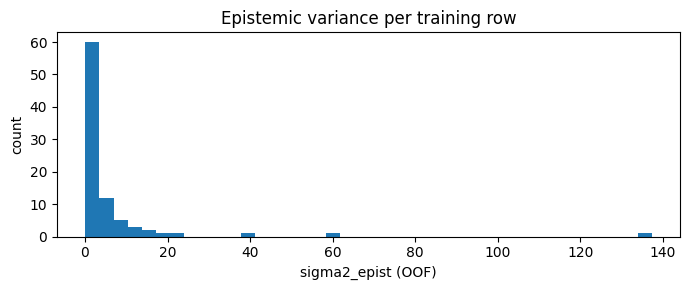

In [16]:
plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

## Assesment comparing with lin

sigma2_epist_oof stats:
  mean   = 8.3610
  median = 3.5250
  max    = 84.9095


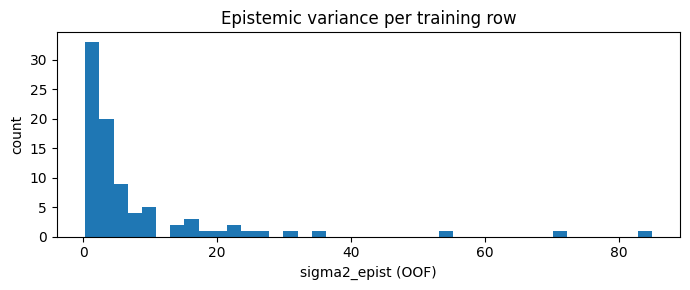

In [17]:
mu_recomputed_lin, sigma2_epist_oof_lin = mdl.compute_mu_and_epistemic_variance(
    preds_matrix=oof_matrix,
    weights=weights,
    use_weights=False,
)

print("sigma2_epist_oof stats:")
print(f"  mean   = {sigma2_epist_oof_lin.mean():.4f}")
print(f"  median = {np.median(sigma2_epist_oof_lin):.4f}")
print(f"  max    = {sigma2_epist_oof_lin.max():.4f}")

plt.figure(figsize=(7, 3))
plt.hist(sigma2_epist_oof_lin, bins=40)
plt.xlabel("sigma2_epist (OOF)")
plt.ylabel("count")
plt.title("Epistemic variance per training row")
plt.tight_layout()
plt.show()

# 6. Build Aleatoric Targets $\tilde r^2$

Each training row gets a noisy point-estimate of the aleatoric variance:

$$\tilde r_i^2 = \max\!\left((y_i - \hat\mu^{\text{OOF}}(\mathbf{x}_i))^2 - \hat\sigma^2_{\text{epist}}(\mathbf{x}_i),\;0\right).$$

Subtracting the epistemic component avoids double-counting it. Truncation at zero handles rows where the ensemble disagreement exceeds the squared residual.

In [18]:
r_tilde_sq, residuals_oof_arr, diag = mdl.build_aleatoric_targets(
    y_true=df[TARGET].values,
    mu_oof=mu_oof.values,
    sigma2_epist_oof=sigma2_epist_oof,
)

print("=== Aleatoric target diagnostics ===")
for k, v in diag.items():
    print(f"  {k:20s} = {v}")

=== Aleatoric target diagnostics ===
  n_total              = 87
  n_truncated          = 41
  pct_truncated        = 47.12643678160919
  r_tilde_sq_min       = 0.0
  r_tilde_sq_max       = 251.24574225548773
  r_tilde_sq_mean      = 13.231272865088995
  r_tilde_sq_median    = 0.04218952521510877


# 7. Train Model B — Aleatoric Variance Predictor

Model B is trained on $\log(\tilde r^2 + \epsilon)$ to keep the regression target well-conditioned (variances are non-negative and right-skewed). Inference back-transforms via $\exp$.

In [19]:
predictor_b = mdl.fit_model_b(
    df=df,
    features=FEATURES,
    r_tilde_sq=r_tilde_sq,
    path=os.path.join(PATH_MODELS, PROCESS, "model_b"),
    presets=PRESETS_B,
    num_bag_folds=NUM_BAG_FOLDS_B,
    num_stack_levels=NUM_STACK_LEVELS_B,
    time_limit=TIME_LIMIT_B,
)

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       8.56 GB / 31.57 GB (27.1%)
Disk Space Avail:   764.24 GB / 932.08 GB (82.0%)
Presets specified: ['best_quality']
Using hyperparameters preset: hyperparameters='zeroshot'
Stack configuration (auto_stack=True): num_stack_levels=0, num_bag_folds=5, num_bag_sets=1
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_iacs\model_b"
Train Data Rows:    87
Train Data Columns: 4
Label Column:       log_r_tilde_sq
AutoGluon infers your prediction problem is: 'regression' (because dtype of label-column == float and many unique label-values observed).
	Label info (max, mi

In [20]:
predictor_b.leaderboard(silent=True)

,model,score_val,eval_metric,pred_time_val,fit_time,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,WeightedEnsemble_L2,-6.874354,root_mean_squared_error,0.137068,15.430392,0.000000,0.009515,2,True,13
1,LightGBM_r131_BAG_L1,-6.980345,root_mean_squared_error,0.007707,1.113410,0.007707,1.113410,1,True,12
2,LightGBM_BAG_L1,-7.077073,root_mean_squared_error,0.008481,0.756940,0.008481,0.756940,1,True,2
3,CatBoost_r177_BAG_L1,-7.112970,root_mean_squared_error,0.001029,1.661570,0.001029,1.661570,1,True,10
4,LightGBMXT_BAG_L1,-7.126210,root_mean_squared_error,0.004356,0.728227,0.004356,0.728227,1,True,1
5,CatBoost_BAG_L1,-7.199192,root_mean_squared_error,0.004071,1.116931,0.004071,1.116931,1,True,4
6,NeuralNetTorch_r79_BAG_L1,-7.275028,root_mean_squared_error,0.027579,5.731965,0.027579,5.731965,1,True,11
7,NeuralNetTorch_BAG_L1,-7.284794,root_mean_squared_error,0.023281,7.104967,0.023281,7.104967,1,True,8
8,LightGBMLarge_BAG_L1,-7.303303,root_mean_squared_error,0.002000,0.688875,0.002000,0.688875,1,True,9
9,NeuralNetFastAI_BAG_L1,-7.419445,root_mean_squared_error,0.043467,6.427466,0.043467,6.427466,1,True,6


# 8. Calibration Diagnostics

Test whether the central α-intervals produced by the predictive Gaussian actually contain the true $y$ on a fraction $\approx \alpha$ of OOF points.

- $\alpha$ here is the **nominal coverage** of an interval (between 0 and 1).
- Empirical coverage **below** nominal ⇒ overconfident (intervals too narrow).
- Empirical coverage **above** nominal ⇒ underconfident (intervals too wide).
- A scalar correction $\hat\sigma \mapsto c \cdot \hat\sigma$ pulls the worst level to nominal; we fit $c$ at $\alpha = 0.9$.

In [21]:
# Build the full OOF predictive distribution.
variance_floor = VARIANCE_FLOOR_FRAC * df[TARGET].var()
sigma2_aleat_oof = mdl.predict_aleatoric_variance(
    predictor_b, df[FEATURES], variance_floor=variance_floor,
)

sigma2_total_oof = sigma2_epist_oof + sigma2_aleat_oof
sigma_total_oof = np.sqrt(sigma2_total_oof)

y_true = df[TARGET].values
cal_before = mdl.calibration_table(
    mu=mu_oof.values, sigma=sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("=== Calibration BEFORE recalibration ===")
print(cal_before)

=== Calibration BEFORE recalibration ===
   alpha  empirical_coverage       gap
0   0.50            0.471264 -0.028736
1   0.80            0.724138 -0.075862
2   0.90            0.839080 -0.060920
3   0.95            0.873563 -0.076437


In [22]:
# Fit a scalar recalibration factor to pull coverage at α=0.9 to nominal.
c_opt = mdl.fit_recalibration_scalar(
    mu=mu_oof.values,
    sigma=sigma_total_oof,
    y_true=y_true,
    target_alpha=RECALIBRATION_TARGET_ALPHA,
)
print(f"Recalibration scalar c = {c_opt:.4f}")

cal_after = mdl.calibration_table(
    mu=mu_oof.values, sigma=c_opt * sigma_total_oof, y_true=y_true,
    alphas=CALIBRATION_ALPHAS,
)
print("\n=== Calibration AFTER recalibration ===")
print(cal_after)

Recalibration scalar c = 1.3712

=== Calibration AFTER recalibration ===
   alpha  empirical_coverage       gap
0   0.50            0.620690  0.120690
1   0.80            0.850575  0.050575
2   0.90            0.908046  0.008046
3   0.95            0.942529 -0.007471


# 9. Inference Example

Use the packaged `predict_with_uncertainty` to apply both models to new rows and return a full predictive distribution. The `recalibration_c` argument scales $\hat\sigma$ to match the calibration above.

In [23]:
df.head(5)

,purity,iacs,temperature,time,iacs_final
0,99.98,97.0,473.0,30.0,100.0
1,99.98,97.0,523.0,600.0,100.0
2,99.98,97.0,573.0,120.0,103.0
3,99.98,96.0,473.0,30.0,99.0
4,99.98,95.0,523.0,600.0,98.0


In [24]:
preds = mdl.predict_with_uncertainty(
    X=df.head(5),
    predictor_a=predictor_a,
    predictor_b=predictor_b,
    weights=weights,
    model_names=base_model_names,
    features=FEATURES,
    variance_floor=variance_floor,
    recalibration_c=c_opt,
    use_weights=USE_WEIGHTED_VARIANCE,
)
preds

,mu,sigma2_epist,sigma2_aleat,sigma2_total,sigma_total
0,99.008824,2.322323,1.433097,7.060714,2.657200
1,99.872978,0.185068,1.433097,3.042376,1.744241
2,100.859552,3.379155,1.433097,9.047704,3.007940
3,98.264358,1.873793,1.433097,6.217415,2.493474
4,98.405765,0.334300,1.433097,3.322953,1.822897


# 10. Persist Artifacts

Save everything that the downstream stages (controller, propagation) will need.

In [25]:
artifacts_path = os.path.join(PATH_MODELS, PROCESS, "artifacts.pkl")
os.makedirs(os.path.dirname(artifacts_path), exist_ok=True)

artifacts = {
    "features": FEATURES,
    "target": TARGET,
    "base_model_names": base_model_names,
    "weights": weights,
    "variance_floor": variance_floor,
    "recalibration_c": c_opt,
    "use_weighted_variance": USE_WEIGHTED_VARIANCE,
    "calibration_before": cal_before,
    "calibration_after": cal_after,
}
with open(artifacts_path, "wb") as f:
    pickle.dump(artifacts, f)

print(f"Saved to: {artifacts_path}")

Saved to: ../../models\annealing_iacs\artifacts.pkl
